In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import truncnorm
from scipy.optimize import minimize
from scipy.stats import norm
import xlwings as xw
import statsmodels.api as sm
import math
from scipy.stats import beta as beta_dist, poisson

             Preco
Data              
1996-09-02  123.09
1996-09-03  119.68
1996-09-04  119.39
1996-09-05  118.42
1996-09-06  118.09
              Preco
Data               
2025-10-13  2219.96
2025-10-14  2301.24
2025-10-15  2314.21
2025-10-16  2269.67
2025-10-17  2262.88


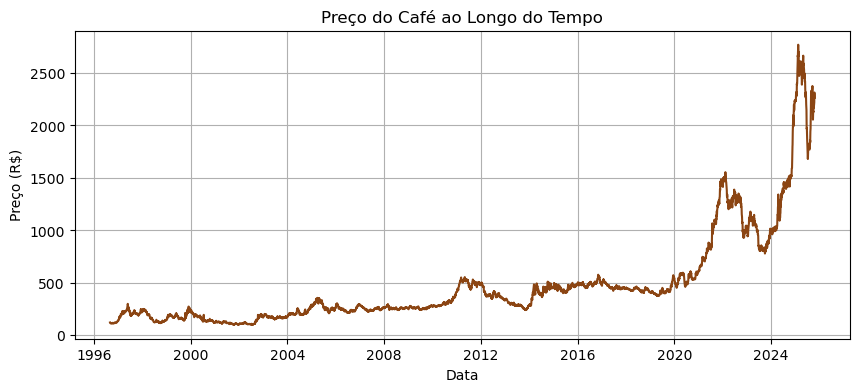

=== Estatísticas Descritivas ===
count    7255.000000
mean      474.544509
std       450.893020
min       101.480000
25%       218.190000
50%       310.620000
75%       489.195000
max      2769.450000

=== Estatísticas dos Retornos Logarítmicos ===
count    7254.000000
mean        0.000401
std         0.018661
min        -0.162006
25%        -0.008008
50%         0.000357
75%         0.008958
max         0.256636


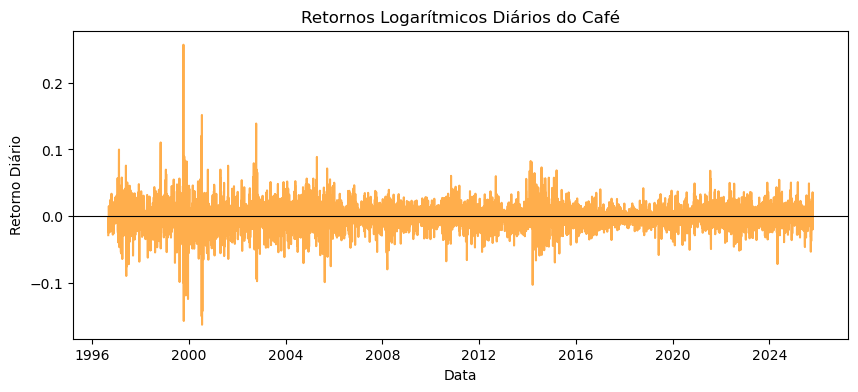

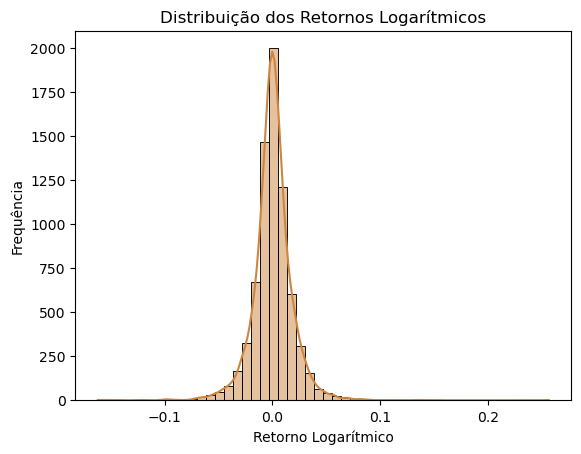

=== Medidas de Forma dos Retornos ===
Curtose (Kurtosis): 11.6924


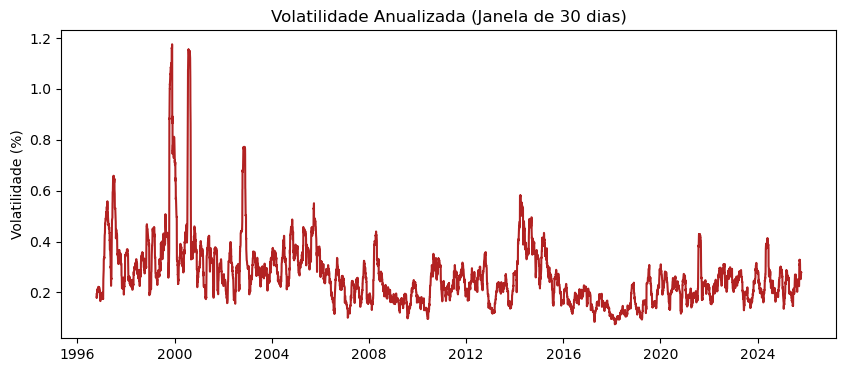


Resumo dos Retornos Logarítmicos:
                       0
Média           0.000401
Desvio-Padrão   0.018661
Assimetria      0.143039
Curtose        11.692431
Min            -0.162006
Max             0.256636


In [3]:
# Ler o arquivo Excel
df = pd.read_excel('Preços café.xls')
df.columns = ['Data', 'Preco']
df['Data'] = pd.to_datetime(df['Data'], format='%d/%m/%Y')
df = df.sort_values('Data').set_index('Data')

# Visualizar início e fim da série
print(df.head())
print(df.tail())

# Plotar a série
plt.figure(figsize=(10,4))
plt.plot(df['Preco'], color='saddlebrown')
plt.title('Preço do Café ao Longo do Tempo')
plt.ylabel('Preço (R$)')
plt.xlabel('Data')
plt.grid(True)
plt.show()

# Estatísticas básicas
print("=== Estatísticas Descritivas ===")
print(df['Preco'].describe().to_string())

# Retornos logarítmicos
df['Retorno_Log'] = np.log(df['Preco'] / df['Preco'].shift(1))
print("\n=== Estatísticas dos Retornos Logarítmicos ===")
print(df['Retorno_Log'].describe().to_string())

# Plot dos retornos
plt.figure(figsize=(10,4))
plt.plot(df['Retorno_Log'], color='darkorange', alpha=0.7)
plt.title('Retornos Logarítmicos Diários do Café')
plt.ylabel('Retorno Diário')
plt.xlabel('Data')
plt.axhline(0, color='black', lw=0.8)
plt.show()

sns.histplot(df['Retorno_Log'].dropna(), bins=50, kde=True, color='peru')
plt.title('Distribuição dos Retornos Logarítmicos')
plt.xlabel('Retorno Logarítmico')
plt.ylabel('Frequência')
plt.show()

print("=== Medidas de Forma dos Retornos ===")
print(f"Curtose (Kurtosis): {kurtosis(df['Retorno_Log'].dropna(), fisher=True):.4f}")

# Volatilidade móvel (desvio-padrão de 30 dias)
df['Volatilidade_30d'] = df['Retorno_Log'].rolling(window=30).std() * np.sqrt(252)  # anualizada
plt.figure(figsize=(10,4))
plt.plot(df['Volatilidade_30d'], color='firebrick')
plt.title('Volatilidade Anualizada (Janela de 30 dias)')
plt.ylabel('Volatilidade (%)')
plt.show()

summary = pd.DataFrame({
    'Média': [df['Retorno_Log'].mean()],
    'Desvio-Padrão': [df['Retorno_Log'].std()],
    'Assimetria': [skew(df['Retorno_Log'].dropna())],
    'Curtose': [kurtosis(df['Retorno_Log'].dropna(), fisher=True)],
    'Min': [df['Retorno_Log'].min()],
    'Max': [df['Retorno_Log'].max()]
})
print("\nResumo dos Retornos Logarítmicos:")
print(summary.T)

In [20]:
# ==============================================================
# 2. FUNÇÃO DE VEROSSIMILHANÇA (μ FIXO = 0)
# ==============================================================

retornos = df['Retorno_Log'].dropna().values

def merton_log_likelihood(params, data):
    sigma, lamb, mu_j, sigma_j = params
    mu = 0  # FIXO
    
    if sigma <= 0 or lamb < 0 or sigma_j <= 0:
        return 1e10
    
    dt = 1
    likelihood = 0
    
    for k in range(10):
        p_k = (np.exp(-lamb * dt) * (lamb * dt)**k) / math.factorial(k)
        
        mu_total = (mu - lamb * mu_j - 0.5 * sigma**2) * dt + k * mu_j
        var_total = (sigma**2 * dt) + k * (sigma_j**2)
        
        likelihood += p_k * norm.pdf(data, loc=mu_total, scale=np.sqrt(var_total))
    
    likelihood = np.maximum(likelihood, 1e-12)
    
    return -np.sum(np.log(likelihood))

# ==============================================================
# 3. ESTIMAÇÃO VIA MLE
# ==============================================================

initial_guess = [retornos.std(), 0.05, 0.0, retornos.std()*2]

result = minimize(
    merton_log_likelihood,
    initial_guess,
    args=(retornos,),
    method='L-BFGS-B',
    bounds=[
        (1e-6, None),  # sigma
        (1e-6, None),  # lambda (removi limite superior 1)
        (None, None),  # mu_j
        (1e-6, None)   # sigma_j
    ]
)

sigma_mle, lamb_mle, muj_mle, sigmaj_mle = result.x

# ==============================================================
# 4. RESULTADOS
# ==============================================================

print("---- Parâmetros Estimados via MLE (μ = 0 fixo) ----")
print(f"μ (drift): 0 (fixado)")
print(f"σ (volatilidade contínua): {sigma_mle:.6f}")
print(f"λ (intensidade de saltos): {lamb_mle:.6f}")
print(f"μ_j (média do salto): {muj_mle:.6f}")
print(f"σ_j (desvio do salto): {sigmaj_mle:.6f}")

---- Parâmetros Estimados via MLE (μ = 0 fixo) ----
μ (drift): 0 (fixado)
σ (volatilidade contínua): 0.008396
λ (intensidade de saltos): 0.642432
μ_j (média do salto): -0.000393
σ_j (desvio do salto): 0.019949


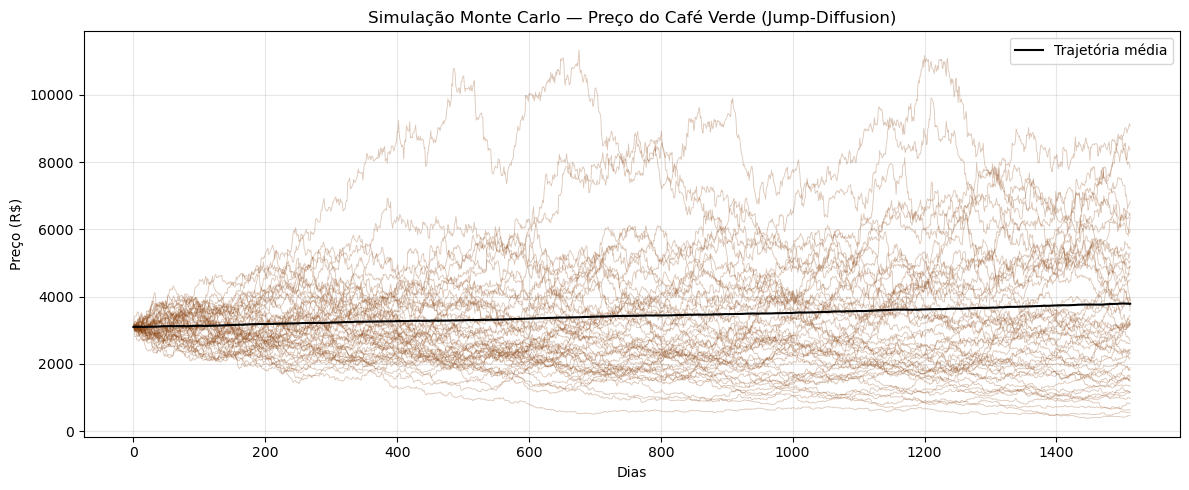


Parâmetros utilizados (escala diária):
  S0     = 3100.00
  μ      = 0.000347
  σ      = 0.008396
  λ      = 0.642432
  μⱼ     = -0.000393
  σⱼ     = 0.019949
  Drift ajustado (μ - λμⱼ) = 0.000253

--- Preço de Venda (PERT) ---
  E(x) teórico = R$ 40.00
  E(x) simulado= R$ 40.0004
  Mín simulado = R$ 38.0160
  Máx simulado = R$ 41.9748


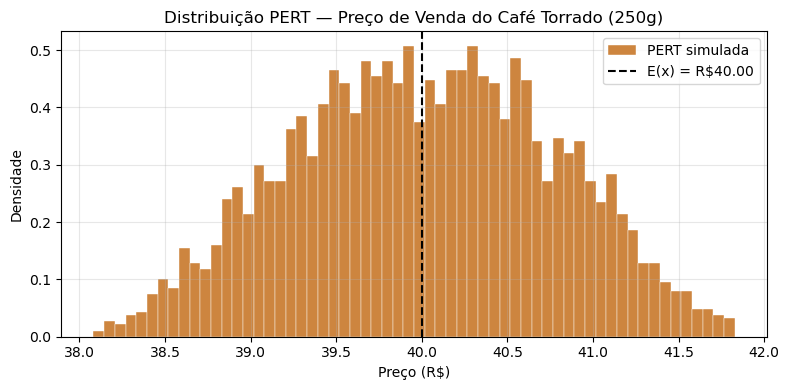


--- Quantidade Vendida (PERT crescente) ---
  Período  1: moda=3.0 | E(x) teórico=3.00 | E(x) simulado=3.0045
  Período 72: moda=13.0 | E(x) teórico=13.00 | E(x) simulado=12.9912


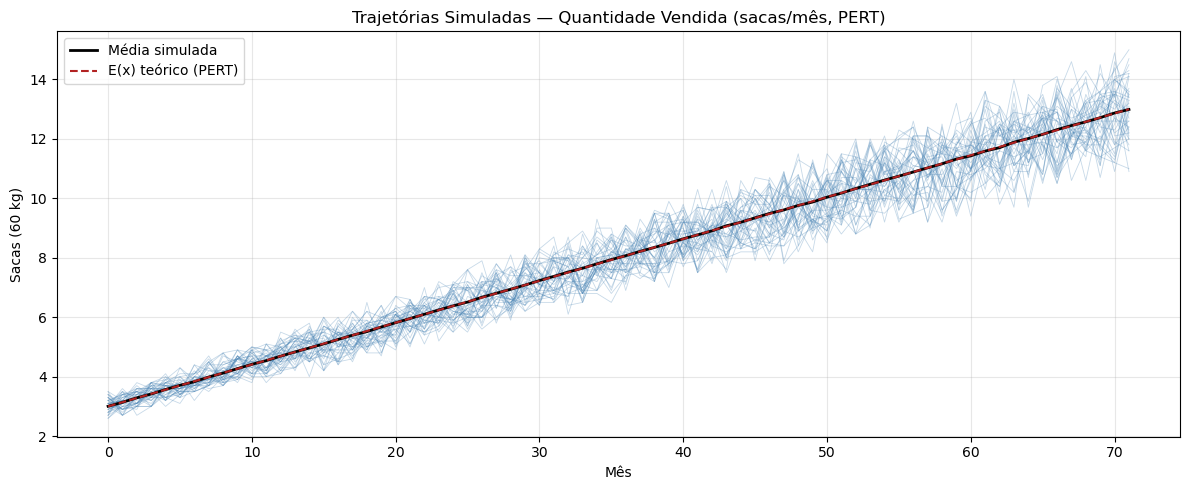


RESUMO DAS DISTRIBUIÇÕES MODELADAS
Variável                       Distribuição         E(x)
------------------------------------------------------------
Preço café verde               Jump-Diffusion       Estocástico
Preço café torrado             PERT                 R$ 40.00
Qtd vendida (início)           PERT                 3.00 sacas/mês
Qtd vendida (fim)              PERT                 13.00 sacas/mês


In [23]:
"""
=============================================================
MODELAGEM DAS 3 DISTRIBUIÇÕES - SIMULAÇÃO MONTE CARLO CAFÉ
=============================================================
Este módulo é um complemento ao notebook Simulação_Monte_Carlo.ipynb.
Assume que os parâmetros MLE (mu_mle, sigma_mle, lamb_mle, muj_mle,
sigmaj_mle) e o preço inicial (S0) já foram estimados nas células
anteriores do notebook.
 
CORREÇÕES aplicadas em relação ao código original:
  1. Preço de venda: triangular → PERT (Beta redimensionada)
  2. Quantidade vendida: truncnorm → PERT com limites ±20% da moda
  3. Adicionada simulação jump-diffusion que gera 'resultados'
  4. dt mantido em escala diária (consistente com MLE onde dt=1)
=============================================================
"""

 
# =============================================================
# FUNÇÃO AUXILIAR: DISTRIBUIÇÃO PERT
# =============================================================
 
def pert_rvs(a, m, b, size):
    """
    Amostra da distribuição PERT via Beta redimensionada.
 
    Parâmetros
    ----------
    a : float ou array — limite inferior
    m : float ou array — moda (valor mais provável)
    b : float ou array — limite superior
    size : int — número de amostras
 
    Retorna
    -------
    np.ndarray de shape (size,)
 
    Fórmula do valor esperado: E(x) = (a + 4m + b) / 6
    Shape parameters da Beta:
        alpha = 1 + 4*(m - a)/(b - a)
        beta  = 1 + 4*(b - m)/(b - a)
    """
    a, m, b = np.asarray(a, float), np.asarray(m, float), np.asarray(b, float)
    if np.any(b <= a):
        raise ValueError("Limite superior 'b' deve ser maior que 'a'.")
    if np.any((m < a) | (m > b)):
        raise ValueError("Moda 'm' deve estar entre 'a' e 'b'.")
 
    alpha = 1 + 4 * (m - a) / (b - a)
    beta  = 1 + 4 * (b - m) / (b - a)
 
    samples = beta_dist.rvs(alpha, beta, size=size)
    return a + (b - a) * samples
 
 
# =============================================================
# DISTRIBUIÇÃO 1: CAFÉ VERDE — JUMP-DIFFUSION (Merton, 1976)
# =============================================================
# NOTA: Esta seção deve ser executada APÓS a estimação MLE
# do notebook original, que gera:
#   sigma_mle, lamb_mle, muj_mle, sigmaj_mle
#
# Ajuste o S0 e n_simulacoes conforme seu contexto.
# =============================================================
 
def simular_jump_diffusion(S0, mu, sigma, lamb, mu_j, sigma_j,
                           n_dias, n_simulacoes, dt=1):
    """
    Simula trajetórias de preço pelo modelo Jump-Diffusion de Merton.
 
    Equação discreta:
        S[t+1] = S[t] * exp( drift_ajustado + sigma*sqrt(dt)*Z + J_t )
 
    Onde:
        drift_ajustado = (mu - lamb*mu_j - 0.5*sigma²) * dt
        J_t = soma de N_t saltos ~ Normal(mu_j, sigma_j)
        N_t ~ Poisson(lamb * dt)
 
    O ajuste (mu - lamb*mu_j) evita dupla contagem do impacto médio
    dos saltos, conforme Merton (1976) e descrito no texto.
 
    Parâmetros em escala DIÁRIA (consistente com MLE onde dt=1).
 
    Parâmetros
    ----------
    S0            : float — preço inicial do café verde
    mu            : float — drift diário estimado via MLE
    sigma         : float — volatilidade contínua diária
    lamb          : float — intensidade de saltos (saltos/dia)
    mu_j          : float — média do tamanho dos saltos (log)
    sigma_j       : float — desvio-padrão do tamanho dos saltos
    n_dias        : int   — número de dias a simular (ex: 6*252=1512)
    n_simulacoes  : int   — número de trajetórias Monte Carlo
    dt            : float — passo de tempo (1 = diário, padrão)
 
    Retorna
    -------
    resultados : np.ndarray de shape (n_simulacoes, n_dias + 1)
    """
    resultados = np.zeros((n_simulacoes, n_dias + 1))
    resultados[:, 0] = S0
 
    # Drift ajustado: remove a parcela média dos saltos para
    # evitar dupla contagem (Merton, 1976)
    drift_ajustado = (mu - lamb * mu_j - 0.5 * sigma**2) * dt
 
    for t in range(n_dias):
        # Componente browniano contínuo
        Z = np.random.standard_normal(n_simulacoes)
        difusao = sigma * np.sqrt(dt) * Z
 
        # Componente de saltos (Poisson + Normal)
        N_t = poisson.rvs(lamb * dt, size=n_simulacoes)
        J_t = np.zeros(n_simulacoes)
 
        idx_saltos = np.where(N_t > 0)[0]
        for i in idx_saltos:
            J_t[i] = np.sum(np.random.normal(mu_j, sigma_j, N_t[i]))
 
        log_retorno = drift_ajustado + difusao + J_t
        resultados[:, t + 1] = resultados[:, t] * np.exp(log_retorno)
 
    return resultados
 
 
# --- EXECUÇÃO ---
 
n_anos       = 6
n_dias_sim   = n_anos * 252          # 1512 dias úteis
n_simulacoes = 3000
 
# S0 = último preço observado da série (ajuste conforme seu df)
S0 = 3100
 
resultados = simular_jump_diffusion(
    S0          = S0,
    mu          = 0,
    sigma       = sigma_mle,
    lamb        = lamb_mle,
    mu_j        = muj_mle,
    sigma_j     = sigmaj_mle,
    n_dias      = n_dias_sim,
    n_simulacoes= n_simulacoes
)
 
# Visualização de trajetórias
plt.figure(figsize=(12, 5))
for i in range(50):
    plt.plot(resultados[i], alpha=0.3, linewidth=0.6, color='saddlebrown')
plt.plot(resultados.mean(axis=0), color='black', linewidth=1.5,
         label='Trajetória média')
plt.title('Simulação Monte Carlo — Preço do Café Verde (Jump-Diffusion)')
plt.xlabel('Dias')
plt.ylabel('Preço (R$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
print(f"\nParâmetros utilizados (escala diária):")
print(f"  S0     = {S0:.2f}")
print(f"  μ      = {mu_mle:.6f}")
print(f"  σ      = {sigma_mle:.6f}")
print(f"  λ      = {lamb_mle:.6f}")
print(f"  μⱼ     = {muj_mle:.6f}")
print(f"  σⱼ     = {sigmaj_mle:.6f}")
print(f"  Drift ajustado (μ - λμⱼ) = {0 - lamb_mle*muj_mle:.6f}")
 
dias_por_mes = 21
n_meses = n_dias_sim // dias_por_mes

# =============================================================
# DISTRIBUIÇÃO 2: PREÇO DO CAFÉ TORRADO — PERT
# =============================================================
# CORREÇÃO: código original usava triangular. Substituído por PERT
# conforme metodologia descrita no texto.
#
# Parâmetros: a=38 (mínimo), m=40 (moda), b=42 (máximo)
# E(x) = (38 + 4*40 + 42) / 6 = 40.00
# =============================================================
 
a_venda = 38.0
m_venda = 40.0
b_venda = 42.0
 
# Gerado para cada simulação e cada mês
preco_venda = np.column_stack([
    pert_rvs(a_venda, m_venda, b_venda, size=n_simulacoes)
    for _ in range(n_meses)
])
 
# Valor esperado teórico
E_preco_venda = (a_venda + 4 * m_venda + b_venda) / 6
print(f"\n--- Preço de Venda (PERT) ---")
print(f"  E(x) teórico = R$ {E_preco_venda:.2f}")
print(f"  E(x) simulado= R$ {preco_venda.mean():.4f}")
print(f"  Mín simulado = R$ {preco_venda.min():.4f}")
print(f"  Máx simulado = R$ {preco_venda.max():.4f}")
 
# Histograma
plt.figure(figsize=(8, 4))
plt.hist(preco_venda[:, 0], bins=60, color='peru', edgecolor='white',
         linewidth=0.3, density=True, label='PERT simulada')
plt.axvline(E_preco_venda, color='black', linestyle='--',
            label=f'E(x) = R${E_preco_venda:.2f}')
plt.title('Distribuição PERT — Preço de Venda do Café Torrado (250g)')
plt.xlabel('Preço (R$)')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
 
# =============================================================
# DISTRIBUIÇÃO 3: QUANTIDADE VENDIDA — PERT COM CRESCIMENTO
# =============================================================
# CORREÇÃO: código original usava truncnorm. Substituído por PERT
# conforme metodologia do texto.
#
# Crescimento: 3 sacas/mês (início) → 13 sacas/mês (6 anos)
# Variabilidade: ±20% da moda em cada período
#   a_t = 0.8 * moda_t
#   b_t = 1.2 * moda_t
# =============================================================
 
moda_inicial = 3.0
moda_final   = 13.0
 
moda_periodo = np.linspace(moda_inicial, moda_final, n_meses)
a_periodo    = 0.8 * moda_periodo   # limite inferior (-20%)
b_periodo    = 1.2 * moda_periodo   # limite superior (+20%)
 
quantidade = np.zeros((n_simulacoes, n_meses))
 
for t in range(n_meses):
    quantidade[:, t] = pert_rvs(
        a=a_periodo[t],
        m=moda_periodo[t],
        b=b_periodo[t],
        size=n_simulacoes
    )
 
quantidade = np.round(quantidade, 1)
 
# Valor esperado teórico por período: (a + 4m + b) / 6 = m (simétrico)
E_quantidade = (a_periodo + 4 * moda_periodo + b_periodo) / 6
 
print(f"\n--- Quantidade Vendida (PERT crescente) ---")
print(f"  Período  1: moda={moda_periodo[0]:.1f} | "
      f"E(x) teórico={E_quantidade[0]:.2f} | "
      f"E(x) simulado={quantidade[:, 0].mean():.4f}")
print(f"  Período {n_meses:2d}: moda={moda_periodo[-1]:.1f} | "
      f"E(x) teórico={E_quantidade[-1]:.2f} | "
      f"E(x) simulado={quantidade[:, -1].mean():.4f}")
 
# Trajetórias simuladas
plt.figure(figsize=(12, 5))
for i in range(40):
    plt.plot(quantidade[i], alpha=0.3, linewidth=0.6, color='steelblue')
plt.plot(quantidade.mean(axis=0), color='black', linewidth=2,
         label='Média simulada')
plt.plot(E_quantidade, color='firebrick', linewidth=1.5,
         linestyle='--', label='E(x) teórico (PERT)')
plt.title('Trajetórias Simuladas — Quantidade Vendida (sacas/mês, PERT)')
plt.xlabel('Mês')
plt.ylabel('Sacas (60 kg)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
 
# =============================================================
# RESUMO DAS DISTRIBUIÇÕES
# =============================================================
 
print("\n" + "="*60)
print("RESUMO DAS DISTRIBUIÇÕES MODELADAS")
print("="*60)
print(f"{'Variável':<30} {'Distribuição':<20} {'E(x)'}")
print("-"*60)
print(f"{'Preço café verde':<30} {'Jump-Diffusion':<20} {'Estocástico'}")
print(f"{'Preço café torrado':<30} {'PERT':<20} R$ {E_preco_venda:.2f}")
print(f"{'Qtd vendida (início)':<30} {'PERT':<20} {E_quantidade[0]:.2f} sacas/mês")
print(f"{'Qtd vendida (fim)':<30} {'PERT':<20} {E_quantidade[-1]:.2f} sacas/mês")
print("="*60)

In [11]:
# -----------------------------
# CONFIGURAÇÕES
# -----------------------------

dias_por_mes = 21
arquivo_excel = "Modelagem Cafés Especiais Teste.xlsx"
aba_excel = "Distribuições"
celula_vpl = "C33"

n_sim = 10

# -----------------------------
# CONECTAR AO EXCEL
# -----------------------------

wb = xw.Book(arquivo_excel)
sheet = wb.sheets[aba_excel]

app = wb.app
app.screen_updating = False
app.calculation = 'manual'
app.display_alerts = False
app.enable_events = False

# -----------------------------
# PREPARAÇÃO
# -----------------------------

traj = resultados[:n_sim]

n_sim_real = traj.shape[0]
n_dias = traj.shape[1]

n_meses = n_dias // dias_por_mes

traj = traj[:, :n_meses * dias_por_mes]

precos_mensais_all = traj.reshape(
    n_sim_real,
    n_meses,
    dias_por_mes
).mean(axis=2)

preco_medio_sim = precos_mensais_all.mean(axis=1)

# -----------------------------
# PREÇO DE VENDA — PERT (corrigido)
# -----------------------------
preco_venda = np.column_stack([
    pert_rvs(38.0, 40.0, 42.0, size=n_sim_real)
    for _ in range(n_meses)
])

# -----------------------------
# QUANTIDADE (SACAS) — PERT (corrigido)
# -----------------------------
moda_periodo = np.linspace(3, 13, n_meses)

quantidade = np.zeros((n_sim_real, n_meses))
for t in range(n_meses):
    quantidade[:, t] = pert_rvs(
        a = 0.8 * moda_periodo[t],
        m = moda_periodo[t],
        b = 1.2 * moda_periodo[t],
        size = n_sim_real
    )

quantidade = np.round(quantidade, 1)

# -----------------------------
# MONTE CARLO
# -----------------------------

vpl_resultados = []

for i in range(n_sim_real):

    for m in range(n_meses):

        col = 4 + m*4  # D,H,L,P...

        sheet.cells(2, col).value = precos_mensais_all[i, m]
        sheet.cells(5, col).value = quantidade[i, m]
        sheet.cells(6, col).value = preco_venda[i, m]

    wb.app.calculate()

    vpl = sheet[celula_vpl].value

    if vpl is not None:
        vpl_resultados.append(float(vpl))

# -----------------------------
# FINALIZAR
# -----------------------------

app.calculation = 'automatic'
app.screen_updating = True
app.enable_events = True

vpl_resultados = np.array(vpl_resultados)

# -----------------------------
# RESULTADOS
# -----------------------------

print("VPL médio:", np.mean(vpl_resultados))
print("Probabilidade VPL negativo:", np.mean(vpl_resultados < 0))
print("Percentil 5%:", np.percentile(vpl_resultados,5))
print("Percentil 95%:", np.percentile(vpl_resultados,95))

tabela_vpl = pd.DataFrame({
    "Simulação": np.arange(1, len(vpl_resultados)+1),
    "VPL": vpl_resultados,
    "Preço médio do café": preco_medio_sim[:len(vpl_resultados)]
})

print("\n=== Alguns VPLs simulados ===")
print(tabela_vpl.head())

VPL médio: 247272.00649
Probabilidade VPL negativo: 0.2
Percentil 5%: -686428.182455
Percentil 95%: 627360.6334950001

=== Alguns VPLs simulados ===
   Simulação          VPL  Preço médio do café
0          1  229054.3332          2978.102528
1          2  524501.4609          2255.368527
2          3 -326082.2525          4300.537820
3          4  242012.6064          2906.761809
4          5  620998.5267          2018.929644



Preço crítico do café (VPL = 0): 3343.8686685092644

Resumo da regressão:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 8.710e+04
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:00:36   Log-Likelihood:                -11775.
No. Observations:                1000   AIC:                         2.355e+04
Df Residuals:                     998   BIC:                         2.356e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

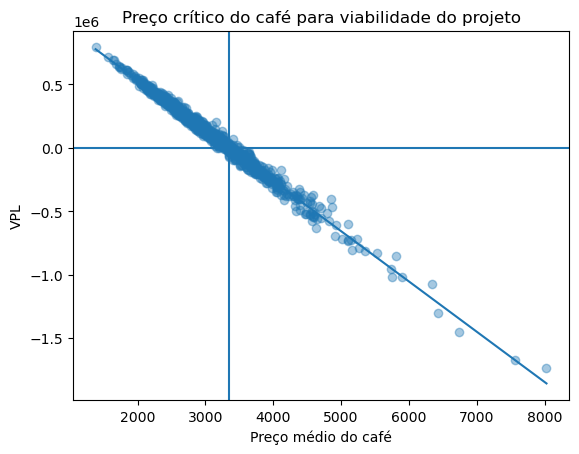

In [26]:
# variável explicativa
X = preco_medio_sim
X = sm.add_constant(X)

# regressão
modelo = sm.OLS(vpl_resultados, X).fit()

alpha = modelo.params[0]
beta = modelo.params[1]

preco_critico = -alpha / beta

print("\nPreço crítico do café (VPL = 0):", preco_critico)
print("\nResumo da regressão:")
print(modelo.summary())